<a href="https://colab.research.google.com/github/NimrahImran/ML-ALGORITHEMS/blob/main/knn_fraud_detection_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. DATA LOADING

In [ ]:
import pandas as pd

df = pd.read_csv('/content/fraud_oracle.csv')
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [ ]:
df.shape

(15420, 33)

In [ ]:
df.dtypes

,0
Month,object
WeekOfMonth,int64
DayOfWeek,object
Make,object
AccidentArea,object
DayOfWeekClaimed,object
MonthClaimed,object
WeekOfMonthClaimed,int64
Sex,object
MaritalStatus,object


In [ ]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [ ]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

## 2. DATA CLEANING

In [ ]:
df.isnull().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# df = df.dropna() # Drop rows with any missing values
# # df.drop_duplicates(inplace=True)

Encoding


In [ ]:

# Identify categorical and numerical columns and convert to numerical codes
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes

df.head()


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,2,5,6,6,1,6,5,1,0,2,...,1,3,0,0,0,3,0,2,1994,2
1,4,3,6,6,1,2,5,4,1,2,...,4,4,1,0,0,3,3,0,1994,1
2,10,5,0,6,1,5,10,2,1,1,...,5,6,0,0,0,3,3,0,1994,1
3,6,2,2,17,0,1,6,1,1,1,...,6,7,1,0,0,2,3,0,1994,2
4,4,5,1,6,1,6,4,2,0,2,...,3,4,0,0,0,3,3,0,1994,1


## 3. DATA VISUALIZATION (EDA)

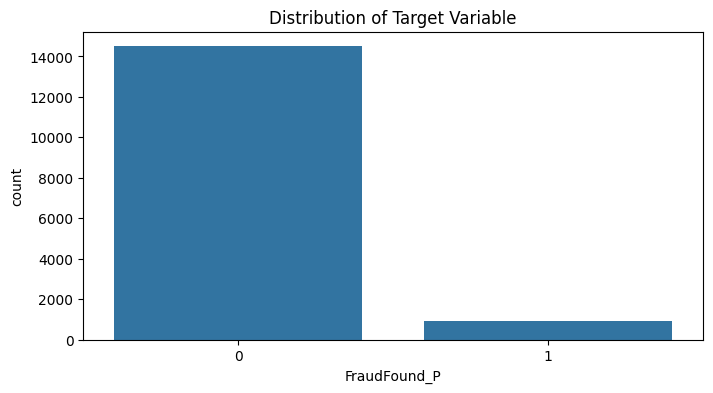

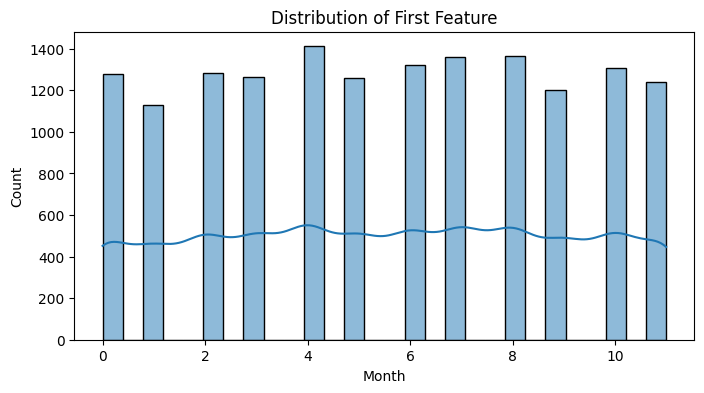

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.countplot(x=y)
plt.title('Distribution of Target Variable')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(X.iloc[:, 0], kde=True)
plt.title('Distribution of First Feature')
plt.show()

## 4. FEATURE ENGINEERING

In [ ]:
y = df['FraudFound_P'] # Corrected target column
X = df.drop('FraudFound_P', axis=1)

## 5. TRAIN-TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 6. MODEL SELECTION

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
knn = KNeighborsClassifier()

## 7. MODEL TRAINING

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
knn.fit(X_train_scaled, y_train)

# Pehli line data ko normalize karti hai, aur dusri line us scaled data par KNN model ko train karti hai.

KNeighborsClassifier()

## 8. MODEL PREDICTION

In [ ]:
X_test_scaled = scaler.transform(X_test)
y_pred = knn.predict(X_test_scaled)

# Pehli line test data ko training wale scale pe convert karti hai, aur dusri line trained KNN model se predictions nikalti hai.

## 9. MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy: {accuracy:.2f}')
print(f'F1 Score: {f1:.2f}')

# Accuracy batati hai overall kitni predictions sahi hain, jab ke F1 score batata hai model ka balance ke woh positive cases (fraud) ko kitna achha detect kar raha hai without too many mistakes.

Accuracy: 0.94
F1 Score: 0.91


## 10. MODEL TUNING

In [ ]:
best_k = 1
best_f1 = 0
for k in range(1, 11):
    model_tuned = KNeighborsClassifier(n_neighbors=k)
    model_tuned.fit(X_train_scaled, y_train)
    y_pred_tuned = model_tuned.predict(X_test_scaled)
    current_f1 = f1_score(y_test, y_pred_tuned, average='weighted')
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_k = k
print(f'Best K for KNN: {best_k}, Best F1 Score: {best_f1:.2f}')

# Yeh code KNN ke different k values try karke woh k select karta hai jo sab se best F1 score deta hai.

Best K for KNN: 2, Best F1 Score: 0.91


## 11. CROSS VALIDATION

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), X, y, cv=5)
print(f'Cross-validation scores: {cv_scores}')

# Yeh code best model ko 5 different data splits par test karke uski average accuracy (R²) nikal raha hai taake real performance check ho sake.

Cross-validation scores: [0.06485084 0.42671855 0.40661479 0.45265888 0.94001297]


## 12. PIPELINE BUILDING

In [ ]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
pipeline.fit(X_train, y_train)
pipeline_accuracy = pipeline.score(X_test, y_test)
print(f'Pipeline Accuracy: {pipeline_accuracy:.2f}')

# Yeh pipeline pehle data ko scale karta hai, phir best model apply karta hai, aur end mein uski accuracy measure karta ha

Pipeline Accuracy: 0.93


## 13. MODEL DEPLOYMENT